# Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, joblib, warnings

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate, train_test_split, learning_curve, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore', category=UserWarning)

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Portnet Imputation Prediction/cleaned_data.csv')

In [ ]:
from huggingface_hub import notebook_login, HfApi, create_repo

notebook_login()

In [6]:
repo_id = "Meliodas-10/portnet-model"
create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

RepoUrl('https://huggingface.co/Meliodas-10/portnet-model', endpoint='https://huggingface.co', repo_type='model', repo_id='Meliodas-10/portnet-model')

# 1- Data Spliting and Modeling Pipeline

In [ ]:
data = pd.read_csv(r'C:\Users\MELIODAS\Desktop\Coding\Machine Learning\Portnet Imputation Prediction\data\processed\cleaned_data.csv')

In [28]:
X = data.drop(columns=['QTE_IMPUTE'])
y = data['QTE_IMPUTE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.24)

print(f'Taille du train set : {X_train.shape[0]} lignes')
print(f'Taille du test set  : {X_test.shape[0]} lignes')

X_train_sample = X_train.sample(n=200000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]


print(f'\nTaille du train sample set : {X_train_sample.shape[0]} lignes')

Taille du train set : 2532817 lignes
Taille du test set  : 799838 lignes

Taille du train sample set : 200000 lignes


In [ ]:
from data_pipeline import modeling_pipeline

# 2- Algorithm Selection

## 2.1- Dummy Model

In [30]:
from sklearn.dummy import DummyRegressor
dummy_regressor = modeling_pipeline.set_params(algorithme=DummyRegressor(strategy='mean'))

dummy_model = TransformedTargetRegressor(
    regressor= dummy_regressor,
    func=np.log1p,
    inverse_func=np.expm1
)

dummy_model.fit(X_train, y_train)

y_pred_baseline = dummy_model.predict(X_test)

mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base = r2_score(y_test, y_pred_baseline)

print("--- BASELINE Score ---")
print(f"MAE  : {mae_base:.2f}")
print(f"RMSE : {rmse_base:.2f}")
print(f"R²   : {r2_base:.4f}")

[_logarithmic_transform] exécuté en 0.111s | Lignes restantes: 2532817
[_impute_and_scale] exécuté en 0.176s | Lignes restantes: 2532817
[_target_encode] exécuté en 0.254s | Lignes restantes: 2532817
[_logarithmic_transform] exécuté en 0.034s | Lignes restantes: 799838
[_impute_and_scale] exécuté en 0.057s | Lignes restantes: 799838
[_target_encode] exécuté en 0.175s | Lignes restantes: 799838
--- BASELINE Score ---
MAE  : 58210.59
RMSE : 551320.48
R²   : -0.0109


## 2.2- Models CV Loop

In [14]:
algorithmes = {
    "Random Forest (Bagging)": RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    "HistGradientBoosting (Boosting)": HistGradientBoostingRegressor(random_state=42)
}

In [15]:
test_slice = X_train.head(5)
target_slice = y_train.head(5)

print("Testing pipeline on a small slice...")
modele_complet = TransformedTargetRegressor(
    regressor=modeling_pipeline.set_params(algorithme=algorithmes["Random Forest (Bagging)"]),
    func=np.log1p,
    inverse_func=np.expm1
)
modele_complet.fit(test_slice, target_slice)
print("\n----- Sanity check passed successfully! The pipeline fits without errors -----")

Testing pipeline on a small slice...
[_logarithmic_transform] exécuté en 0.001s | Lignes restantes: 5
[_impute_and_scale] exécuté en 0.003s | Lignes restantes: 5
[_target_encode] exécuté en 0.001s | Lignes restantes: 5

----- Sanity check passed successfully! The pipeline fits without errors -----


In [16]:
for nom, algo in algorithmes.items():
    print(f"\n--- Entraînement de {nom} en cours (CV = 5) ---")
    modeling_pipeline.set_params(algorithme=algo)

    modele_complet = TransformedTargetRegressor(
        regressor=modeling_pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )

    scores = cross_validate(
        modele_complet, 
        X_train_sample, 
        y_train_sample, 
        cv=5, 
        scoring=('neg_mean_absolute_error', 'r2'),
        n_jobs=1
    )
 
    mae_moyen = -scores['test_neg_mean_absolute_error'].mean()
    r2_moyen = scores['test_r2'].mean()
    
    print(f"[{nom}] R² Moyen  : {r2_moyen:.4f}")
    print(f"[{nom}] MAE Moyen : {mae_moyen:.2f} unités")

## Results:
Random Forest (Bagging):
* R² Moyen  : 0.8686
* MAE Moyen : 14569.53 unités


HistGradientBoosting (Boosting):
* R² Moyen  : 0.7668
* MAE Moyen : 21491.05 unités

### --> Decision : Random Forest

# 3- Optimization

In [17]:
modeling_pipeline.set_params(algorithme=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))

model = TransformedTargetRegressor(
    regressor=modeling_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

param_distributions = {
    'regressor__algorithme__n_estimators': [100, 200, 300],
    'regressor__algorithme__max_depth': [15, 25, None],
    'regressor__algorithme__min_samples_split': [2, 5, 10],
    'regressor__algorithme__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=5,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1
)

In [18]:
print("--- Début de l'optimisation des hyperparamètres ---")
random_search.fit(X_train_sample, y_train_sample)

print(f"\nMeilleurs paramètres trouvés : {random_search.best_params_}")
print(f"Meilleur score R² (CV) : {random_search.best_score_:.4f}")

best_params = {k.replace('regressor__', ''): v for k, v in random_search.best_params_.items()}
modeling_pipeline.set_params(**best_params)

with open("best_params.json", "w") as f:
    json.dump(best_params, f)

api = HfApi()
api.upload_file(
    path_or_fileobj="best_params.json",
    path_in_repo="best_params.json",
    repo_id=repo_id,
    repo_type="model"
)

print("\nParamètres sauvegardés avec succès sur Hugging Face !")

# 4- Model Refitting

In [19]:
for param, value in modeling_pipeline.named_steps['algorithme'].get_params().items():
    print(f"{param}: {value}")

bootstrap: True
ccp_alpha: 0.0
criterion: squared_error
max_depth: 15
max_features: 1.0
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 4
min_samples_split: 5
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 200
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


In [20]:
full_model = TransformedTargetRegressor(
    regressor=modeling_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

print("\n--- Entraînement du modèle final sur l'intégralité du dataset ---")
full_model.fit(X_train, y_train)


--- Entraînement du modèle final sur l'intégralité du dataset ---
[_logarithmic_transform] exécuté en 0.063s | Lignes restantes: 2532817
[_impute_and_scale] exécuté en 0.154s | Lignes restantes: 2532817
[_target_encode] exécuté en 0.301s | Lignes restantes: 2532817


TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      PortNetDataPreprocessing()),
                                                     ('algorithme',
                                                      RandomForestRegressor(max_depth=15,
                                                                            min_samples_leaf=4,
                                                                            min_samples_split=5,
                                                                            n_estimators=200,
                                                                            n_jobs=-1,
                                                                            random_state=42))]))

# 5- Model Saving

In [ ]:
joblib.dump(full_model, "portnet_model.pkl")
api = HfApi()

api.upload_file(
    path_or_fileobj="portnet_model.pkl",
    path_in_repo="portnet_model.pkl",
    repo_id=repo_id,
    repo_type="model"
)
print("modèle sauvegardés avec succès sur Hugging Face !")

# 6- Validation

In [23]:
print("--- Lancement de la Validation Croisée (CV = 5) ---")

cv_results = cross_validate(
    full_model,
    X_train, 
    y_train,
    cv=5,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    },
    n_jobs=-1,
    verbose=3
)

print("Validation croisée terminée avec succès !")

--- Lancement de la Validation Croisée (CV = 5) ---


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 89.0min remaining: 133.6min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 89.2min finished


Validation croisée terminée avec succès !


In [24]:
folds_r2 = cv_results['test_r2']
folds_mae = -cv_results['test_neg_mean_absolute_error'] if 'test_neg_mean_absolute_error' in cv_results else -cv_results['test_mae']
folds_rmse = -cv_results['test_neg_root_mean_squared_error'] if 'test_neg_root_mean_squared_error' in cv_results else -cv_results['test_rmse']

print("\n" + "="*50)
print("RAPPORT DE VALIDATION DIAGNOSTIQUE (CV = 5)")
print("="*50)
for i in range(5):
    print(f"Pli {i+1} -> R²: {folds_r2[i]:.4f} | MAE: {folds_mae[i]:,.2f} | RMSE: {folds_rmse[i]:,.2f}")

print("-"*50)
print(f"Moyenne R²   : {folds_r2.mean():.4f} (± {folds_r2.std():.4f})")
print(f"Moyenne MAE  : {folds_mae.mean():,.2f} (± {folds_mae.std():,.2f})")
print(f"Moyenne RMSE : {folds_rmse.mean():,.2f} (± {folds_rmse.std():,.2f})")
print("="*50)


RAPPORT DE VALIDATION DIAGNOSTIQUE (CV = 5)
Pli 1 -> R²: 0.8940 | MAE: 12,780.82 | RMSE: 178,571.90
Pli 2 -> R²: 0.8947 | MAE: 12,952.85 | RMSE: 178,474.60
Pli 3 -> R²: 0.9020 | MAE: 12,836.33 | RMSE: 170,629.26
Pli 4 -> R²: 0.8942 | MAE: 12,896.32 | RMSE: 176,006.22
Pli 5 -> R²: 0.9043 | MAE: 13,007.03 | RMSE: 170,183.93
--------------------------------------------------
Moyenne R²   : 0.8979 (± 0.0044)
Moyenne MAE  : 12,894.67 (± 80.47)
Moyenne RMSE : 174,773.18 (± 3,684.68)


## Results:
* Pli 1 -> R²: 0.8940 | MAE: 12,780.82 | RMSE: 178,571.90
* Pli 2 -> R²: 0.8947 | MAE: 12,952.85 | RMSE: 178,474.60
* Pli 3 -> R²: 0.9020 | MAE: 12,836.33 | RMSE: 170,629.26
* Pli 4 -> R²: 0.8942 | MAE: 12,896.32 | RMSE: 176,006.22
* Pli 5 -> R²: 0.9043 | MAE: 13,007.03 | RMSE: 170,183.93


## Metrics:
* Moyenne R²   : 0.8979 (± 0.0044)
* Moyenne MAE  : 12,894.67 (± 80.47)
* Moyenne RMSE : 174,773.18 (± 3,684.68)

### --> Decision : Model Perfectly Stable 99,9 %

# 7-Lurning Curve

--- Génération de la Learning Curve (120 min) ---


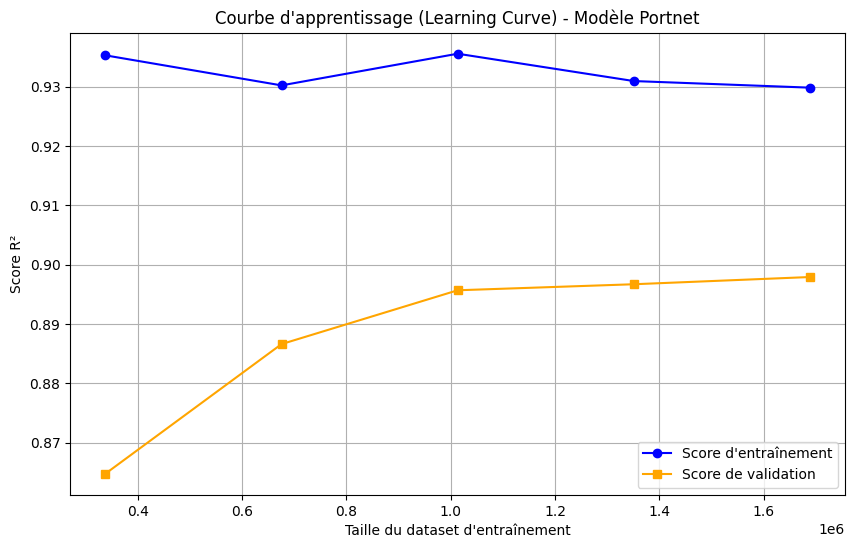

In [31]:
print("--- Génération de la Learning Curve (120 min) ---")

train_sizes, train_scores, val_scores = learning_curve(
    full_model, 
    X_train, 
    y_train, 
    cv=3, 
    scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

# Calcul des moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Tracé du graphique
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Score d'entraînement", marker='o', color='blue')
plt.plot(train_sizes, val_mean, label="Score de validation", marker='s', color='orange')

plt.title("Courbe d'apprentissage (Learning Curve) - Modèle Portnet")
plt.xlabel("Taille du dataset d'entraînement")
plt.ylabel("Score R²")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# END